# Fitness Calorie Expenditure Analysis

## Project Overview

This project investigates which factors are associated with calorie expenditure during exercise sessions.

Using 973 workout sessions, the analysis combines SQL-based exploratory data analysis with Python statistical modeling to examine the relationships between calorie expenditure, session duration, average heart rate, age, weight, and workout type.

### Research Question

> Which factors are associated with higher calorie expenditure?

Because the dataset is observational, this analysis identifies associations rather than causal effects.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

from sklearn.metrics import mean_absolute_error, mean_squared_error

## 1. Data Preparation

The dataset contains workout sessions with information about participant characteristics, workout type, heart rate, session duration, and calories burned.

In [3]:
df = pd.read_csv("/content/gym_members_exercise_tracking-selected-columns.csv")

print(f"Dataset dimensions: {df.shape}")
df.head()

Dataset dimensions: (973, 10)


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       973 non-null    int64  
 1   Gender                    973 non-null    object 
 2   Weight (kg)               973 non-null    float64
 3   Height (m)                973 non-null    float64
 4   Max_BPM                   973 non-null    int64  
 5   Avg_BPM                   973 non-null    int64  
 6   Resting_BPM               973 non-null    int64  
 7   Session_Duration (hours)  973 non-null    float64
 8   Calories_Burned           973 non-null    float64
 9   Workout_Type              973 non-null    object 
dtypes: float64(4), int64(4), object(2)
memory usage: 76.1+ KB


## 2. Exploratory Data Analysis

Exploratory analysis was performed to examine the relationships between calorie expenditure and key workout characteristics, including session duration, average heart rate, and workout type.

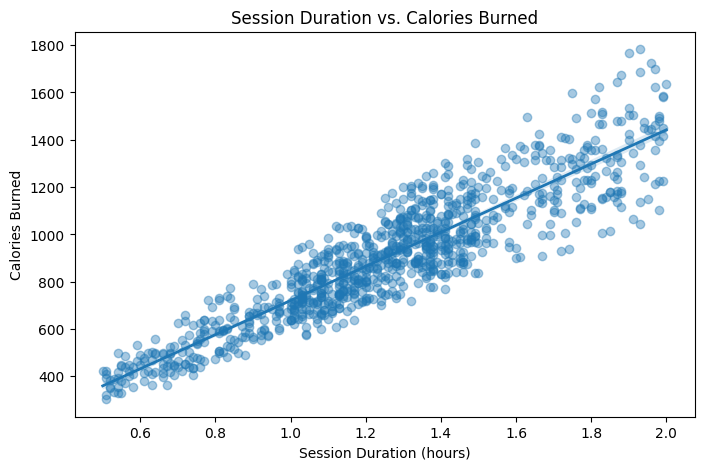

In [5]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x="Session_Duration (hours)",
    y="Calories_Burned",
    scatter_kws={"alpha": 0.4},
    line_kws={"linewidth": 2}
)

plt.xlabel("Session Duration (hours)")
plt.ylabel("Calories Burned")
plt.title("Session Duration vs. Calories Burned")
plt.show()

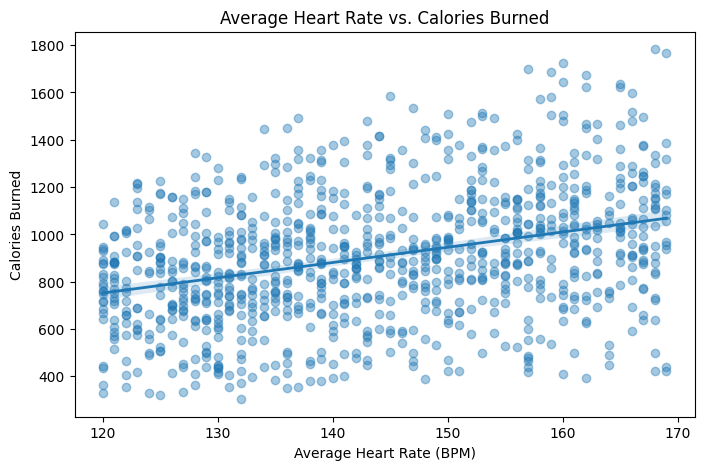

In [6]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x="Avg_BPM",
    y="Calories_Burned",
    scatter_kws={"alpha": 0.4},
    line_kws={"linewidth": 2}
)

plt.xlabel("Average Heart Rate (BPM)")
plt.ylabel("Calories Burned")
plt.title("Average Heart Rate vs. Calories Burned")
plt.show()

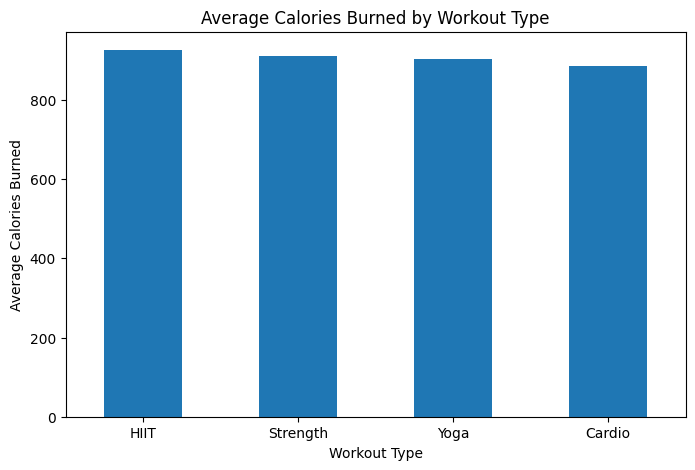

In [7]:
workout_summary = (
    df.groupby("Workout_Type")["Calories_Burned"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

workout_summary.plot(kind="bar")

plt.xlabel("Workout Type")
plt.ylabel("Average Calories Burned")
plt.title("Average Calories Burned by Workout Type")
plt.xticks(rotation=0)
plt.show()

### Correlation Analysis

Pearson correlations were calculated to quantify the linear association between calorie expenditure and key numerical variables.

In [13]:
correlations = df[
    [
        "Session_Duration (hours)",
        "Avg_BPM",
        "Weight (kg)",
        "Max_BPM",
        "Calories_Burned"
    ]
].corr()["Calories_Burned"].sort_values(ascending=False)

correlations

,Calories_Burned
Calories_Burned,1.000000
Session_Duration (hours),0.908140
Avg_BPM,0.339659
Weight (kg),0.095443
Max_BPM,0.002090


## 3. Multiple Linear Regression

A multiple linear regression model was used to examine the association between calorie expenditure and several predictors simultaneously.

The model included:

- Session duration
- Average BPM
- Weight
- Age
- Workout type

The model allows the association between each predictor and calorie expenditure to be examined while controlling for the other variables.

In [8]:
model = smf.ols(
    'Calories_Burned ~ Q("Session_Duration (hours)") + Avg_BPM + Q("Weight (kg)") + Age + C(Workout_Type)',
    data=df
).fit(cov_type="HC3")

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        Calories_Burned   R-squared:                       0.962
Model:                            OLS   Adj. R-squared:                  0.962
Method:                 Least Squares   F-statistic:                     2298.
Date:                Thu, 01 Oct 2026   Prob (F-statistic):               0.00
Time:                        19:38:41   Log-Likelihood:                -5241.1
No. Observations:                 973   AIC:                         1.050e+04
Df Residuals:                     965   BIC:                         1.054e+04
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

## 4. Model Diagnostics

The regression residuals were examined to assess whether the model assumptions were reasonably satisfied.

A Breusch-Pagan test indicated significant heteroskedasticity in the residuals. Therefore, HC3 heteroskedasticity-robust standard errors were used for statistical inference.

Variance Inflation Factors (VIFs) were also examined. All predictor VIFs were approximately 1, indicating no meaningful multicollinearity among the predictors.

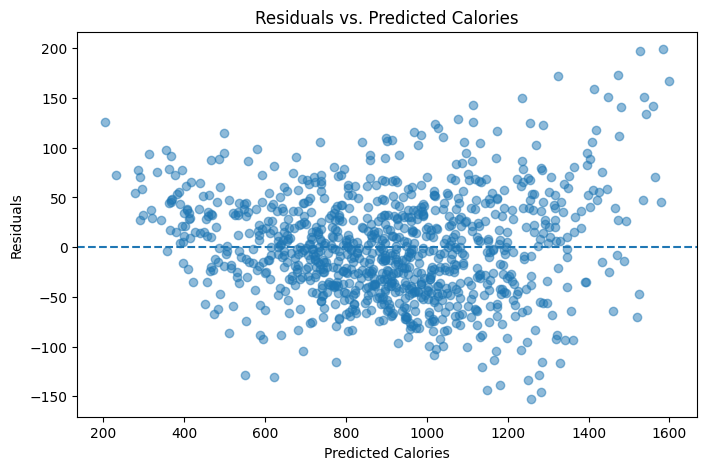

In [9]:
residuals = model.resid
fitted = model.fittedvalues

plt.figure(figsize=(8, 5))

plt.scatter(fitted, residuals, alpha=0.5)
plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Calories")
plt.ylabel("Residuals")
plt.title("Residuals vs. Predicted Calories")

plt.show()

In [12]:
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# Breusch-Pagan test
bp_test = het_breuschpagan(model.resid, model.model.exog)

print(f"LM Statistic: {bp_test[0]:.3f}")
print(f"LM p-value: {bp_test[1]:.3e}")
print(f"F Statistic: {bp_test[2]:.3f}")
print(f"F p-value: {bp_test[3]:.3e}")

LM Statistic: 82.566
LM p-value: 4.124e-15
F Statistic: 12.783
F p-value: 9.027e-16


### Variance Inflation Factors (VIF)

Variance Inflation Factors (VIFs) were calculated to assess multicollinearity among the numerical predictors. VIF values close to 1 indicate little to no multicollinearity.

In [14]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[
    [
        "Age",
        "Weight (kg)",
        "Avg_BPM",
        "Session_Duration (hours)"
    ]
]

vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif

,Variable,VIF
0,Age,1.003091
1,Weight (kg),1.001658
2,Avg_BPM,1.001704
3,Session_Duration (hours),1.000890


## 5. Model Performance

Model performance was evaluated using mean absolute error (MAE) and root mean squared error (RMSE).

These metrics measure the difference between the model's fitted values and the observed calorie expenditure. Because these calculations use the same data used to fit the model, they represent in-sample model performance rather than out-of-sample predictive performance.

In [10]:
predicted = model.fittedvalues
actual = df["Calories_Burned"]

mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))

print(f"R-squared: {model.rsquared:.3f}")
print(f"MAE: {mae:.2f} calories")
print(f"RMSE: {rmse:.2f} calories")

R-squared: 0.962
MAE: 41.90 calories
RMSE: 52.86 calories


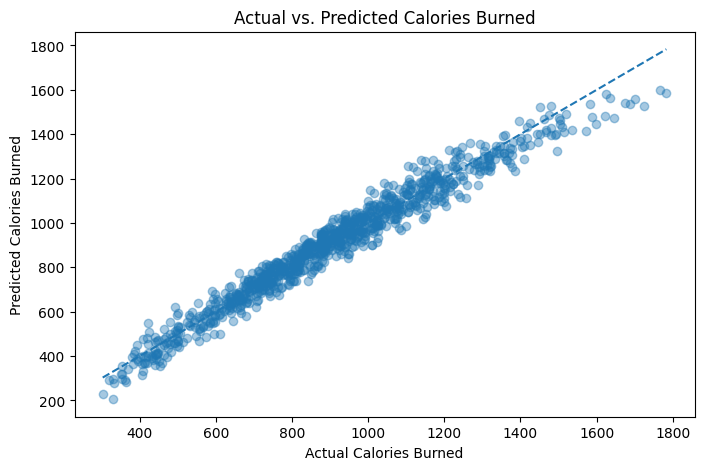

In [11]:
plt.figure(figsize=(8, 5))

plt.scatter(actual, predicted, alpha=0.4)

plt.plot(
    [actual.min(), actual.max()],
    [actual.min(), actual.max()],
    linestyle="--"
)

plt.xlabel("Actual Calories Burned")
plt.ylabel("Predicted Calories Burned")
plt.title("Actual vs. Predicted Calories Burned")

plt.show()

## 6. Conclusion

Session duration was the strongest factor associated with calorie expenditure in this dataset. Average heart rate, weight, and age also showed statistically significant associations after controlling for the other variables.

Workout type showed differences in raw average calorie expenditure, but these differences were not statistically significant after accounting for session duration, average BPM, weight, and age.

The final regression model explained approximately 96.2% of the observed variation in calorie expenditure. The model had an in-sample MAE of approximately 41.9 calories and an RMSE of approximately 52.9 calories.

The residual analysis indicated heteroskedasticity, so HC3 robust standard errors were used for statistical inference. VIF values were approximately 1, indicating no meaningful multicollinearity among the predictors.

Because the dataset is observational, these results describe associations rather than causal relationships. The model's performance metrics are also based on the same observations used to fit the model and therefore do not measure out-of-sample predictive performance.

## 7. Key Findings

- **Session duration** had the strongest relationship with calorie expenditure, with a Pearson correlation of **0.908**.
- **Average heart rate** had a moderate positive correlation with calorie expenditure (**0.340**).
- **Weight** had a weaker positive correlation with calorie expenditure (**0.095**).
- Workout types had relatively similar raw average calorie expenditures, ranging from approximately **885 to 926 calories per session**.
- In the multiple regression model, session duration, average BPM, weight, and age showed statistically significant associations with calorie expenditure after controlling for the other predictors.
- Workout type was not statistically significant after controlling for the other predictors.
- The regression model explained **96.2% of the observed variation** in calorie expenditure.
- The model had an in-sample **MAE of 41.9 calories** and **RMSE of 52.9 calories**.